# Hierarchical gridworld task-family playground

This notebook scaffolds a fixed four-task family crossed along two latent factors:

| | Gain maximization | Loss avoidance |
|---|---|---|
| **Deterministic transitions** | forest foraging | safe navigation |
| **Stochastic transitions** | windy foraging | ice hazards |

The audited default 10×10 tasks share start, exit, action set, state indexing,
horizon, and step cost. Their walls differ, while outcome maps retain the intended
default factorial matching. The editor makes every visible task property independent
by default, so alternative designs need not retain that coupling. The environments
keep the generic Gymnasium interface used by the supplied reference agents.

In [1]:
from collections import Counter
import json
import random

import matplotlib.pyplot as plt
import numpy as np

from hierarchical_gridworld import (
    HierarchicalGridWorld,
    audit_task_family_difficulty,
    load_task_family,
    make_task_environments,
    make_default_task_family,
    plot_task,
    save_task_family,
    validate_task_family,
)
from task_designer import TaskDesigner
from stochastic_crp_dyna_agent import AgentConfig, StochasticSoftmaxCRPDyna
from recovery import (
    simulate_diner,
    simulate_fresh_start,
    simulate_persistent,
)

SEED = 2026
np.random.seed(SEED)
random.seed(SEED)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load the four versioned task specifications

`four_task_family.json` is the shared stimulus definition. If it is absent, the
code creates the editable starting template. The validator permits task-specific
starts, exits, walls, outcomes, horizons, slip, and costs. It rejects incompatible
state encodings or an incomplete 2×2 crossing.

In [2]:
from pathlib import Path

FAMILY_PATH = Path('four_task_family.json')
if FAMILY_PATH.exists():
    specs = load_task_family(FAMILY_PATH)
else:
    specs = make_default_task_family()
    save_task_family(specs, FAMILY_PATH)

summary = validate_task_family(specs)
print(summary)
for name, spec in specs.items():
    print(f'{name:20s}: {spec.transition_mode:13s} × {spec.objective_mode:14s}; '
          f'slip={spec.slip_prob:.2f}; outcomes={len(spec.outcomes)}')

saved_payload = json.loads(FAMILY_PATH.read_text())
stored_difficulty_audit = saved_payload.get('difficulty_audit')
if stored_difficulty_audit is None:
    print('Stored difficulty audit: none (expected during fast design iteration)')
else:
    print('Stored difficulty flag:',
          'ACCEPTABLE' if stored_difficulty_audit['acceptable'] else 'REVISE')
print(f"Distinct wall layouts: {summary['n_distinct_wall_layouts']}")
print(f"Distinct outcome maps: {summary['n_distinct_outcome_layouts']}")

{'n_tasks': 4, 'interface_matched': True, 'geometry_matched': False, 'walls_matched': False, 'n_distinct_wall_layouts': 4, 'outcomes_matched': False, 'n_distinct_outcome_layouts': 2, 'start_matched': True, 'terminals_matched': True, 'horizon_matched': True, 'factor_pairs': [('deterministic', 'gain'), ('deterministic', 'loss_avoidance'), ('stochastic', 'gain'), ('stochastic', 'loss_avoidance')], 'size': 10, 'start': (9, 5), 'starts': {'deterministic_gain': (9, 5), 'deterministic_loss': (9, 5), 'stochastic_gain': (9, 5), 'stochastic_loss': (9, 5)}, 'terminals': [(0, 5)], 'terminals_by_task': {'deterministic_gain': [(0, 5)], 'deterministic_loss': [(0, 5)], 'stochastic_gain': [(0, 5)], 'stochastic_loss': [(0, 5)]}, 'n_walls': {'deterministic_gain': 23, 'deterministic_loss': 23, 'stochastic_gain': 23, 'stochastic_loss': 23}, 'n_outcomes': {'deterministic_gain': 4, 'deterministic_loss': 4, 'stochastic_gain': 4, 'stochastic_loss': 4}}
deterministic_gain  : deterministic × gain          ; slip

## 2. Designer view versus participant/agent view

The first figure reveals the hidden outcome map for stimulus construction. During
an actual episode, the agent receives only discrete state, signed feedback after a
transition, and termination/truncation. Context names and factor labels are omitted
from `info` by default.

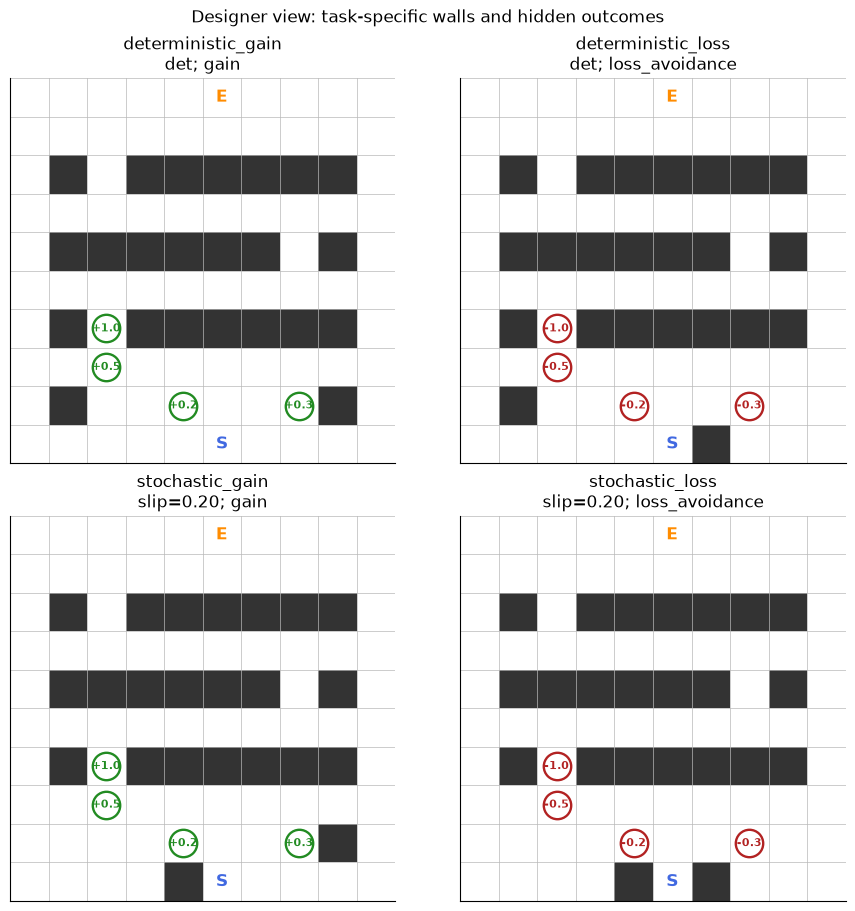

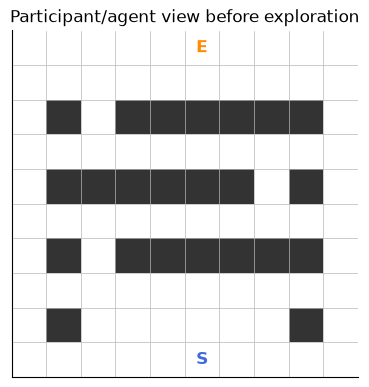

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9), constrained_layout=True)
for ax, (name, spec) in zip(axes.flat, specs.items()):
    plot_task(spec, ax, reveal_outcomes=True)
fig.suptitle('Designer view: task-specific walls and hidden outcomes')
plt.show()

fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_task(next(iter(specs.values())), ax, reveal_outcomes=False,
          title='Participant/agent view before exploration')
plt.show()

## 3. Visualize how the same action maps to the next state

The maps below show the exact next-position distribution for selecting **UP** at
the shared start. The deterministic task has one possible next state; the slippery
task allocates 20% probability across the other actions. Walls and boundaries can
combine several executed actions into the same observed next state.

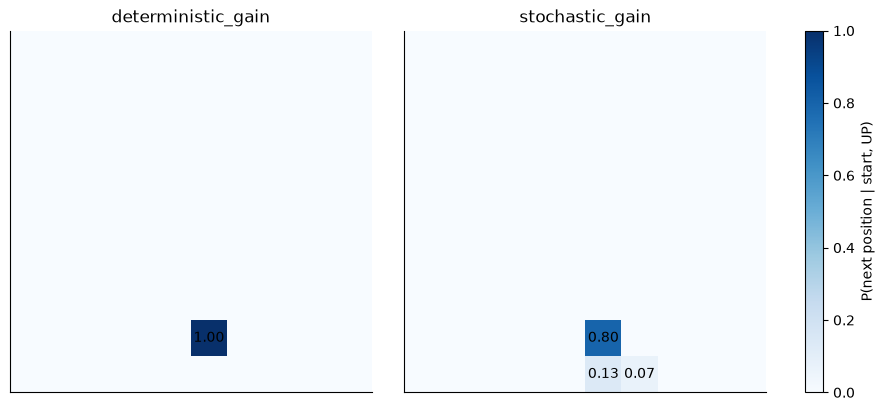

In [4]:
def transition_probability_grid(env, state, action):
    grid = np.zeros((env.size, env.size))
    for next_state, probability in env.transition_distribution(state, action).items():
        row, column = env.state_to_position(next_state)
        grid[row, column] += probability
    return grid

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
for ax, task_name in zip(axes, ['deterministic_gain', 'stochastic_gain']):
    env = HierarchicalGridWorld(specs[task_name])
    start_state, _ = env.reset(seed=SEED)
    probabilities = transition_probability_grid(env, start_state, action=0)
    image = ax.imshow(probabilities, vmin=0, vmax=1, cmap='Blues')
    for row in range(env.size):
        for column in range(env.size):
            if probabilities[row, column] > 0:
                ax.text(column, row, f'{probabilities[row,column]:.2f}',
                        ha='center', va='center')
    ax.set(xticks=[], yticks=[], title=task_name)
fig.colorbar(image, ax=axes, label='P(next position | start, UP)')
plt.show()

### Changing slippery motion

There are three equivalent places to control slip:

- persistent design setting: change `spec.slip_prob` before constructing an environment;
- one-off sensitivity run: `HierarchicalGridWorld(spec, slip_prob=0.35)`;
- family-level runtime overrides: pass a dictionary to `make_task_environments`.

The widget slider edits only the active stochastic task by default. Its adjacent
link checkbox explicitly copies changes across the same transition context. The
slider is disabled for deterministic tasks. Slips use uniform action substitution.

In [5]:
# Runtime example: this does not modify specs or the JSON file.
slip_demo = make_task_environments(
    specs,
    seed=SEED,
    slip_prob_overrides={
        'stochastic_gain': 0.35,
        'stochastic_loss': 0.35,
    },
)
print('Stored slip:', specs['stochastic_gain'].slip_prob)
print('Runtime slip:', slip_demo['stochastic_gain'].slip_prob)
print('P(execute intended action):',
      slip_demo['stochastic_gain'].action_execution_probs(0)[0])

Stored slip: 0.2
Runtime slip: 0.35
P(execute intended action): 0.65


### Does the wall design actually give the probe information?

The heatmap summarizes the four compulsory start probes. A value is the probability
that the agent remains at the start after requesting an action. `DOWN` is blocked by
the grid boundary in every scene. The task-specific left/right gates create distinct
signatures, while stochastic substitution softens rather than erases them.

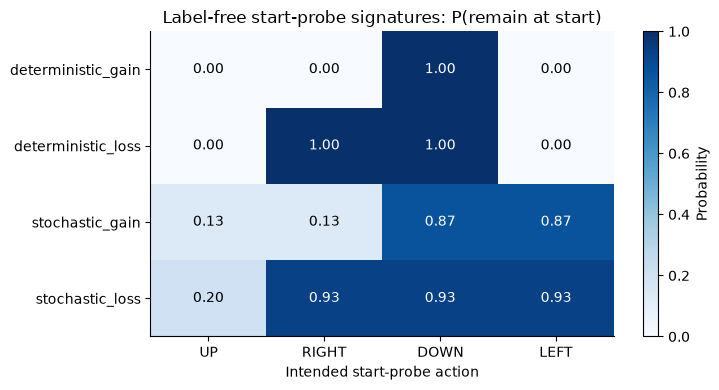

In [6]:
action_labels = ['UP', 'RIGHT', 'DOWN', 'LEFT']
probe_signatures = np.zeros((len(specs), 4))
for row, (name, spec) in enumerate(specs.items()):
    env = HierarchicalGridWorld(spec)
    start_state, _ = env.reset(seed=SEED)
    for action in range(4):
        distribution = env.transition_distribution(start_state, action)
        probe_signatures[row, action] = distribution.get(start_state, 0.0)

fig, ax = plt.subplots(figsize=(7.5, 4))
image = ax.imshow(probe_signatures, vmin=0, vmax=1, cmap='Blues', aspect='auto')
for row in range(probe_signatures.shape[0]):
    for column in range(probe_signatures.shape[1]):
        value = probe_signatures[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center',
                color='white' if value > 0.55 else 'black')
ax.set(
    xticks=range(4), xticklabels=action_labels,
    yticks=range(len(specs)), yticklabels=list(specs),
    xlabel='Intended start-probe action',
    title='Label-free start-probe signatures: P(remain at start)',
)
fig.colorbar(image, ax=ax, label='Probability')
plt.tight_layout(); plt.show()

## 4. Interactive task-family designer

- Start, exit, wall, outcome, slip, and step-cost edits affect only the selected
  task by default.
- Every cross-task propagation control is an explicit opt-in. Switching tasks never
  copies the current task's settings.
- Outcome layouts may be completely different. Their coordinate union is maintained
  as an invisible shared inventory index so state integers remain interoperable.
- **Validate and save (fast)** checks the schema and 2×2 crossing, then writes JSON
  without solving the MDP. The saved `difficulty_audit` field is `null`.
- **Audit difficulty** is independent and intentionally slower. It updates the widget
  report and path preview but is not required for saving.
- **Designer view** reveals outcome values; **participant view** hides them.

Because the one-time outcome inventory is a bitmask, `m` unique outcome coordinates
produce `100 × 2^m` states in a 10×10 task. Independent maps are supported, but a
small shared coordinate pool keeps simulation and recovery practical.

The initial JSON should be treated as a template until the group agrees on the
task mechanics and freezes a version for simulations.

In [8]:
designer = TaskDesigner(specs, export_path=str(FAMILY_PATH))
designer.display()

## 5. Optional pre-agent audit and best-route visualization

Run the next cell when you want the expensive known-MDP check. It uses the current
in-memory widget design, even if you have not saved it. The audit reports worst,
uniformly random, and optimal expected returns, plus optimal exit probability and
matched-factor comparability.

The blue trace is an actual optimal path in deterministic scenes. In slippery
scenes it is the nominal intended-action trace; the exact optimal policy branches
after slips, so expected return and exit probability are the authoritative metrics.

You may skip this cell for quick schema or agent-interface smoke tests. A design
should not be described as difficulty-matched or frozen for data collection until
this audit has been run and reviewed.

Difficulty flag: REVISE
transition within gain          : gap Δ=0.027, exit Δ=0.000, comparable=True
transition within loss_avoidance: gap Δ=0.348, exit Δ=0.000, comparable=False
objective  within deterministic : gap Δ=0.103, exit Δ=0.000, comparable=True
objective  within stochastic    : gap Δ=0.272, exit Δ=0.000, comparable=False


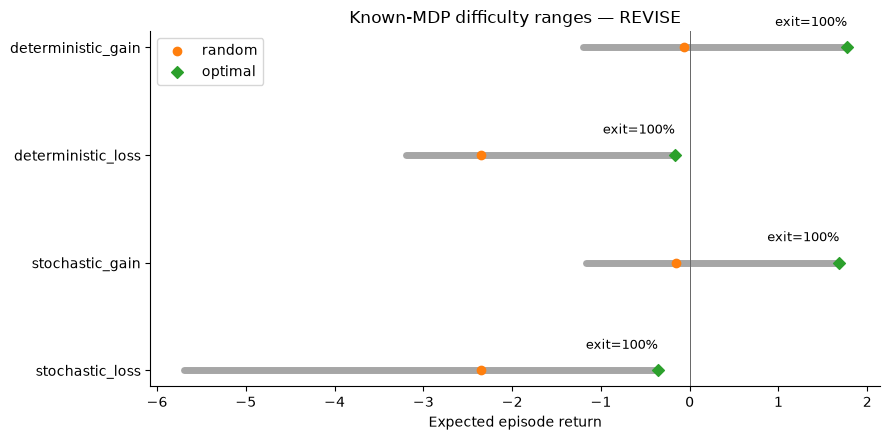

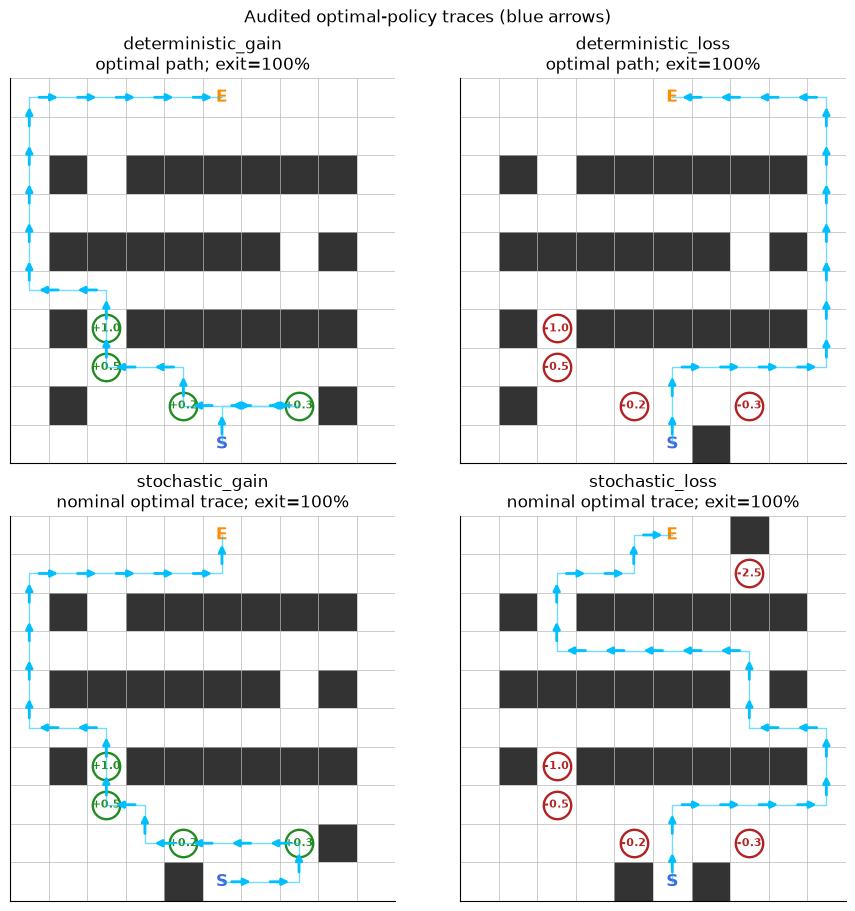

In [12]:
AUDIT_TOLERANCE = 0.15
audit_specs = designer.editor.specs
validate_task_family(audit_specs)
difficulty_audit = audit_task_family_difficulty(
    audit_specs, tolerance=AUDIT_TOLERANCE
)

print('Difficulty flag:',
      'ACCEPTABLE' if difficulty_audit['acceptable'] else 'REVISE')
for comparison in difficulty_audit['comparisons']:
    print(f"{comparison['factor']:10s} within {comparison['matched_on']:14s}: "
          f"gap Δ={comparison['normalized_gap_difference']:.3f}, "
          f"exit Δ={comparison['optimal_exit_difference']:.3f}, "
          f"comparable={comparison['comparable']}")

fig, ax = plt.subplots(figsize=(9, 4.5))
for row, (name, metrics) in enumerate(difficulty_audit['tasks'].items()):
    ax.plot([metrics['worst_return'], metrics['optimal_return']], [row, row],
            color='0.65', linewidth=5, solid_capstyle='round')
    ax.scatter(metrics['random_return'], row, color='tab:orange', marker='o',
               label='random' if row == 0 else None, zorder=3)
    ax.scatter(metrics['optimal_return'], row, color='tab:green', marker='D',
               label='optimal' if row == 0 else None, zorder=3)
    ax.text(metrics['optimal_return'], row - 0.20,
            f"exit={metrics['optimal_exit_probability']:.0%}",
            ha='right', fontsize=9)
ax.axvline(0, color='0.4', linewidth=0.7)
ax.set(
    yticks=range(len(difficulty_audit['tasks'])),
    yticklabels=list(difficulty_audit['tasks']),
    xlabel='Expected episode return',
    title=('Known-MDP difficulty ranges — ' +
           ('ACCEPTABLE' if difficulty_audit['acceptable'] else 'REVISE')),
)
ax.invert_yaxis(); ax.legend(); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(9, 9), constrained_layout=True)
for ax, (name, spec) in zip(axes.flat, audit_specs.items()):
    trace = difficulty_audit['tasks'][name]['optimal_trace']
    plot_task(
        spec,
        ax,
        reveal_outcomes=True,
        optimal_path=trace['positions'],
        title=(f"{name}\n"
               f"{'optimal path' if spec.transition_mode == 'deterministic' else 'nominal optimal trace'}; "
               f"exit={trace['exit_probability']:.0%}"),
    )
fig.suptitle('Audited optimal-policy traces (blue arrows)')
plt.show()

# Optional: persist these exact audit results alongside the current design.
# save_task_family(audit_specs, FAMILY_PATH, difficulty_audit=difficulty_audit)

## 6. Use the environments with the supplied reference agents

The generic constructor returns the same `envs: Dict[str, env]` structure expected
by `simulate_fresh_start`, `simulate_persistent`, and `simulate_diner` from
`recovery.py`. These are the reference notebook's softmax agents.

This cell is only an interface smoke test. The original DINER implementation uses
hard transition contradictions and stores one deterministic outcome per state-action;
on slippery tasks it can over-split contexts. That is a model limitation to address,
not an environment incompatibility.

Reference-agent interface smoke test completed.
DINER assignments: [0, 1, 2, 3, 0, 1, 4, 5]


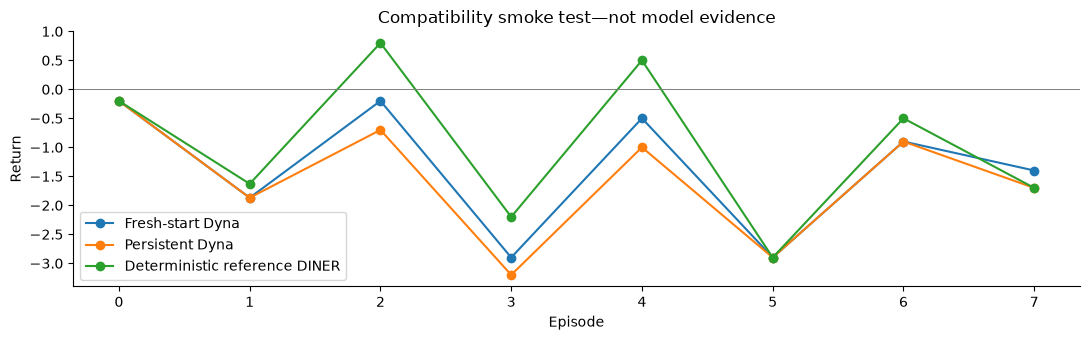

In [13]:
run_specs = designer.editor.specs
validate_task_family(run_specs)  # fast structural gate; no MDP audit
envs = make_task_environments(run_specs, seed=SEED)
env_sequence = list(run_specs) * 2

fresh_returns, _ = simulate_fresh_start(
    env_sequence, envs, eta=0.30, gamma=0.95, tau=0.50,
    planning_steps=3, seed=SEED,
)
persistent_returns, _ = simulate_persistent(
    env_sequence, envs, eta=0.30, gamma=0.95, tau=0.50,
    planning_steps=3, seed=SEED,
)
diner_returns, diner_assignments, _ = simulate_diner(
    env_sequence, envs, crp_alpha=0.5, eta=0.30, gamma=0.95,
    tau=0.50, planning_steps=3, n_probe=8, seed=SEED,
)

print('Reference-agent interface smoke test completed.')
print('DINER assignments:', diner_assignments)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(fresh_returns, marker='o', label='Fresh-start Dyna')
ax.plot(persistent_returns, marker='o', label='Persistent Dyna')
ax.plot(diner_returns, marker='o', label='Deterministic reference DINER')
ax.axhline(0, color='0.5', linewidth=0.7)
ax.set(xlabel='Episode', ylabel='Return', title='Compatibility smoke test—not model evidence')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Stochastic softmax CRP-Dyna

`StochasticSoftmaxCRPDyna` completes the stochastic scaffold from the recovery
tutorial rather than merely replacing the deterministic model with transition counts:

- repeated samples learn each probe distribution by
  `P ← P + η_m(one_hot(next_state) - P)`;
- mean Jensen–Shannon divergence reports graded fingerprint separation;
- Bayesian assignment combines the CRP prior (`n_k` versus `α`) with a smoothed
  categorical probe likelihood, retaining an explicit new-cluster option;
- the Dyna transition model uses a separate delta-rule learning rate `model_eta`;
- actions follow `softmax(Q/τ)`;
- Dyna planning samples learned stochastic transitions.

It receives the same state, action, feedback, and termination stream as the other agents and
never reads the true task or factor labels. This remains a **flat** CRP over complete
task models; it is the appropriate stochastic baseline before implementing separate
transition and outcome CRPs.

Played 36 episodes; inferred 4 contexts.
Mean return: -1.080555555555553
Last-probe JSD to existing contexts: [0.462 0.242 0.235 0.115]


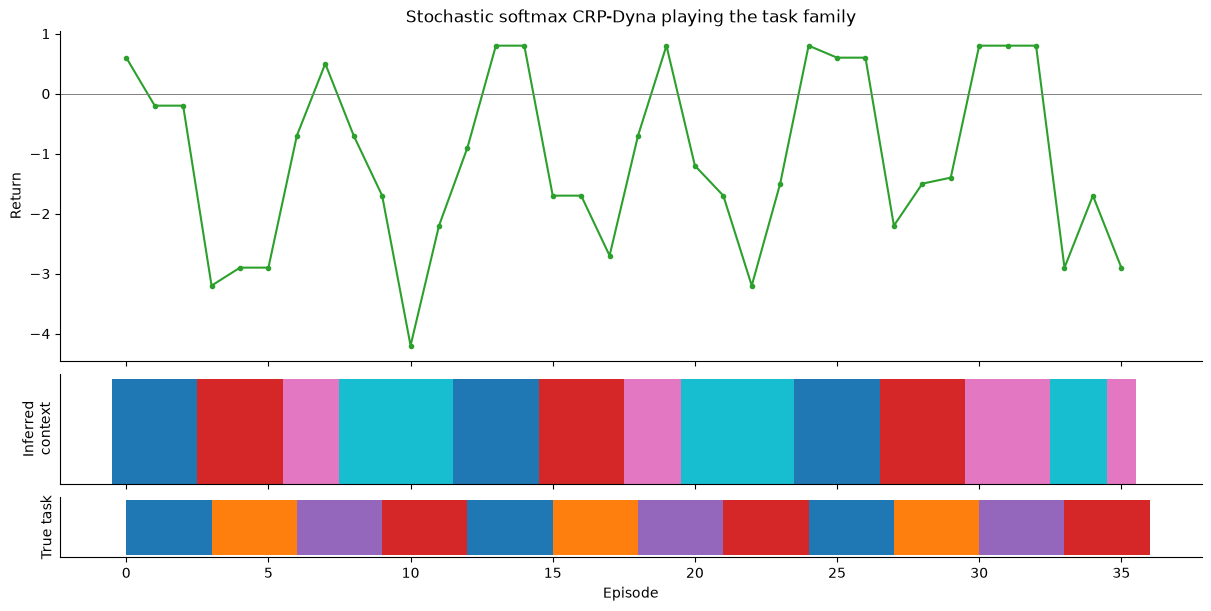

In [14]:
run_specs = designer.editor.specs
validate_task_family(run_specs)  # fast structural gate; no MDP audit
soft_envs = make_task_environments(run_specs, seed=SEED + 100)
soft_sequence = []
for cycle in range(3):
    for task_name in run_specs:
        soft_sequence.extend([task_name] * 3)

first_env = next(iter(soft_envs.values()))
soft_config = AgentConfig(
    eta=0.30,
    gamma=0.95,
    tau=0.15,
    crp_alpha=0.50,
    planning_steps=5,
    n_probe=12,
    probe_samples_per_step=5,
    probe_eta=0.30,
    model_eta=0.30,
    assignment_mode='sample',
)
soft_agent = StochasticSoftmaxCRPDyna(
    first_env.observation_space.n,
    first_env.action_space.n,
    soft_config,
    seed=SEED,
)
soft_result = soft_agent.play_sequence(soft_sequence, soft_envs)
print(f'Played {len(soft_sequence)} episodes; inferred {len(soft_agent.contexts)} contexts.')
print('Mean return:', np.mean(soft_result.returns))
if soft_result.probe_distances[-1].size:
    print('Last-probe JSD to existing contexts:',
          np.round(soft_result.probe_distances[-1], 3))

fig, axes = plt.subplots(
    3, 1, figsize=(12, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 1, 0.55]}, constrained_layout=True,
)
axes[0].plot(soft_result.returns, color='tab:green', marker='o', markersize=3)
axes[0].axhline(0, color='0.5', linewidth=0.7)
axes[0].set(ylabel='Return', title='Stochastic softmax CRP-Dyna playing the task family')

cluster_colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(soft_agent.contexts))))
for episode, assignment in enumerate(soft_result.assignments):
    axes[1].bar(episode, 1, color=cluster_colors[assignment], width=1)
axes[1].set(yticks=[], ylabel='Inferred\ncontext')

task_colors = dict(zip(run_specs, ['tab:blue', 'tab:orange', 'tab:purple', 'tab:red']))
for episode, task_name in enumerate(soft_sequence):
    axes[2].barh(0, 1, left=episode, color=task_colors[task_name], height=0.8)
axes[2].set(yticks=[], xlabel='Episode', ylabel='True task')
plt.show()

## 8. Agent comparison and schedule design

The repository intentionally supports four agent variants:

1. Fresh-start Dyna: no cross-task transfer.
2. Persistent Dyna: indiscriminate full pooling.
3. Deterministic reference DINER: reusable whole-task contexts, hard probe
   contradictions, and one stored next state per state-action pair.
4. Stochastic DINER: delta-rule probe distributions, graded JSD diagnostics,
   Bayesian CRP assignment, and probabilistic Dyna replay.

Use the smoke cells only to verify interfaces. For model comparisons, use the same
pre-registered schedule and parameter ranges for all agents, rebuild freshly seeded
environment objects for each simulation, and repeat across many seeds or synthetic
participants. The deterministic reference DINER is deliberately misspecified on
slippery tasks and should be treated as a baseline rather than the final stochastic
model.

## 9. Frozen design choices and remaining decisions

- Outcomes are collected once; the collection bitmask is part of the discrete state
  (`100 × 2⁴ = 1,600` states for the four-coordinate audited default).
- Context and factor labels are not included in the observation or ordinary `info`.
- Episodes end on reaching the exit or truncate at `max_steps`, matching the reference
  task contract.
- Slippery motion uses uniform substitution across all four actions; the intended
  action therefore retains its base probability plus its share of the slip mass.
- Wall geometry is not globally coupled. The default left/right start gates are
  factorial context cues: left tracks stochasticity and right tracks loss frame.
  Because this cueing can make inference easier, compare it against a no-gate or
  cue-remapped control before attributing an advantage to abstract structure learning.
- Decide whether task themes are visible context cues or only cover stories; cueing
  must be explicit if it becomes an experimental factor.
- Match attainable return ranges and optimal-policy difficulty across gain and loss
  frames; otherwise valence is confounded with task difficulty.